In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۶: نفرین بُعد و اثر آن بر KNN

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

KNN بر این ایده تکیه دارد که مثال‌های نزدیک از مثال‌های دور معنادارترند. نفرین بُعد این ایده را به چالش می‌کشد. با رشد تعداد ویژگی‌ها، داده تنک می‌شود، فاصله‌ها کنتراست خود را از دست می‌دهند، همسایگی محلی اطلاعات کم‌تری دارد و ذخیره یا جست‌وجوی بردارهای ویژگی گران‌تر می‌شود. مسئله این نیست که دادهٔ پُربعد ممنوع است؛ مسئله این است که فاصلهٔ ساده ممکن است دیگر شباهت مفید را نمایش ندهد.

در این درس اثر را با شبیه‌سازی کنترل‌شده و دادهٔ واقعی مخزن می‌بینیم. اندازه می‌گیریم با رشد بُعد فاصلهٔ نزدیک‌ترین و دورترین چگونه به هم نزدیک می‌شوند، ویژگی نامرتبط به طبقه‌بندی اضافه می‌کنیم، افت دقت KNN را می‌بینیم و راه‌کارهایی مانند انتخاب ویژگی و PCA را مقایسه می‌کنیم. سپس از iris.csv استفاده می‌کنیم تا نشان دهیم حتی دادهٔ کوچک و تمیز با افزودن بُعدهای تصادفی می‌تواند عملکرد KNN را از دست بدهد.

درس عملی این است: ستون بیشتر خودبه‌خود اطلاعات بیشتر نیست. هر ویژگی هندسه، اعتبارسنجی، ذخیره‌سازی و معنای همسایه را عوض می‌کند.

,dimensions,nearest_distance,farthest_distance,mean_distance,relative_contrast
0,1,0.000,3.269,0.815,9330.352
1,2,0.060,3.678,1.484,60.250
2,5,0.476,4.907,2.216,9.314
3,10,1.961,6.541,4.138,2.335
4,20,3.420,8.838,6.057,1.584
5,50,6.393,11.587,9.263,0.813
6,100,11.703,16.858,14.133,0.441
7,200,16.780,22.159,19.630,0.321


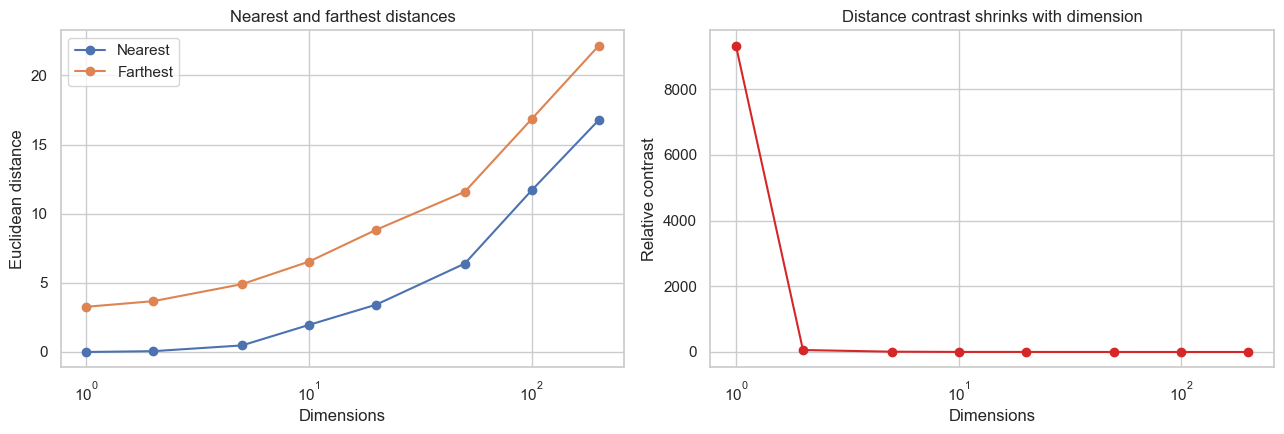

In [3]:
dimension_grid = [1, 2, 5, 10, 20, 50, 100, 200]
distance_rows = []
for dimension in dimension_grid:
    points = rng.normal(size=(600, dimension))
    query = points[0]
    distances = np.linalg.norm(points[1:] - query, axis=1)
    distance_rows.append({
        "dimensions": dimension,
        "nearest_distance": distances.min(),
        "farthest_distance": distances.max(),
        "mean_distance": distances.mean(),
        "relative_contrast": (distances.max() - distances.min()) / distances.min(),
    })
distance_summary = pd.DataFrame(distance_rows)
display(distance_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(distance_summary["dimensions"], distance_summary["nearest_distance"], marker="o", label="Nearest")
axes[0].plot(distance_summary["dimensions"], distance_summary["farthest_distance"], marker="o", label="Farthest")
axes[0].set_xscale("log")
axes[0].set_xlabel("Dimensions")
axes[0].set_ylabel("Euclidean distance")
axes[0].set_title("Nearest and farthest distances")
axes[0].legend()
axes[1].plot(distance_summary["dimensions"], distance_summary["relative_contrast"], marker="o", color="tab:red")
axes[1].set_xscale("log")
axes[1].set_xlabel("Dimensions")
axes[1].set_ylabel("Relative contrast")
axes[1].set_title("Distance contrast shrinks with dimension")
plt.tight_layout()
plt.show()

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. نفرین بُعد را با دادهٔ تنک و تمرکز فاصله توضیح دهید.
2. با رشد بُعد، فاصلهٔ نزدیک‌ترین، دورترین و میانگین را اندازه بگیرید.
3. نشان دهید ویژگی نامرتبط چگونه دقت KNN را کم می‌کند.
4. توضیح دهید چرا مقیاس‌بندی اطلاعات نامرتبط یا تکراری را درست نمی‌کند.
5. با اعتبارسنجی، نمایش تمیز، نویزی و کاهش‌یافته را مقایسه کنید.
6. توضیح دهید PCA چگونه کمک می‌کند و چه زمانی اطلاعات مفید را دور می‌ریزد.
7. اثر بُعد بر حافظه و هزینهٔ پیش‌بینی را برآورد کنید.
8. راه‌کارهایی مانند انتخاب ویژگی، representation learning، همسایهٔ تقریبی و اعتبارسنجی بهتر را انتخاب کنید.

بُعد فقط عددی در جدول نیست. معنای فاصله را عوض می‌کند و بنابراین پایهٔ مدل مبتنی بر نمونه را تغییر می‌دهد.

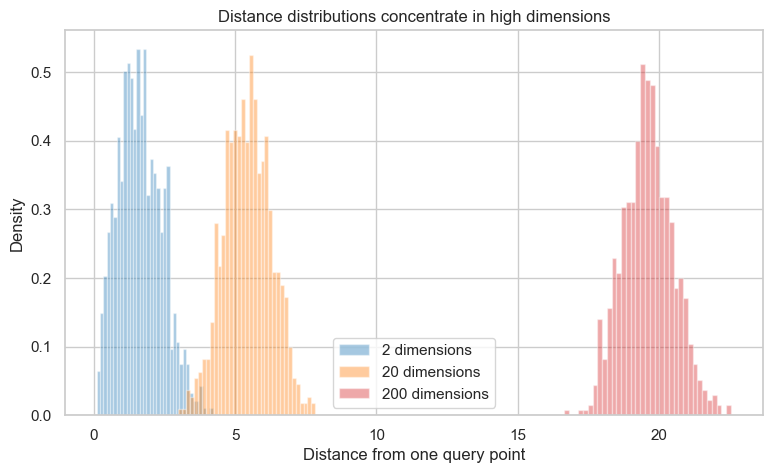

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for dimension, color in zip([2, 20, 200], ["tab:blue", "tab:orange", "tab:red"]):
    points = rng.normal(size=(800, dimension))
    distances = np.linalg.norm(points[1:] - points[0], axis=1)
    ax.hist(distances, bins=35, density=True, alpha=0.4, color=color, label=f"{dimension} dimensions")
ax.set_xlabel("Distance from one query point")
ax.set_ylabel("Density")
ax.set_title("Distance distributions concentrate in high dimensions")
ax.legend()
plt.show()

## ۱. تمرکز فاصله

یک نقطهٔ پرس‌وجو و مشاهده‌های تصادفی فراوان را در نظر بگیرید. در بُعد کم، نزدیک‌ترین نقطه می‌تواند از دورترین نقطه بسیار نزدیک‌تر باشد. در بُعد زیاد، تفاوت نزدیک‌ترین و دورترین نسبت به خود فاصله کوچک می‌شود. خلاصهٔ مفید، کنتراست نسبی است:

$$
\text{relative contrast}=\frac{d_{\max}-d_{\min}}{d_{\min}}.
$$

وقتی کنتراست نسبی کوچک است، نامیدن یک نقطه به‌عنوان نزدیک‌ترین قدرت تفکیک کم‌تری دارد. ممکن است نزدیک‌ترین نقطه از نظر مطلق یا عملی چندان نزدیک نباشد. این تمرکز فاصله، یکی از جنبه‌های مهم نفرین بُعد است.

اثر به توزیع، معیار، هم‌بستگی ویژگی و پیش‌پردازش وابسته است. قانونی نیست که همهٔ مسئله‌های پُربعد شکست بخورند. embeddingهای مدرن وقتی برای نزدیک‌کردن همسایه‌های معنایی آموزش دیده‌اند در بُعد بالا خوب کار می‌کنند. اما بُعدهای بدون ساختار، نامرتبط یا بد مقیاس‌شده KNN معمولی را شکننده‌تر می‌کنند.

,noise_features,total_features,mean_accuracy,std_accuracy
0,0,2,0.987,0.007
1,2,4,0.979,0.008
2,5,7,0.969,0.010
3,10,12,0.971,0.012
4,20,22,0.949,0.015
5,50,52,0.871,0.025
6,100,102,0.771,0.021


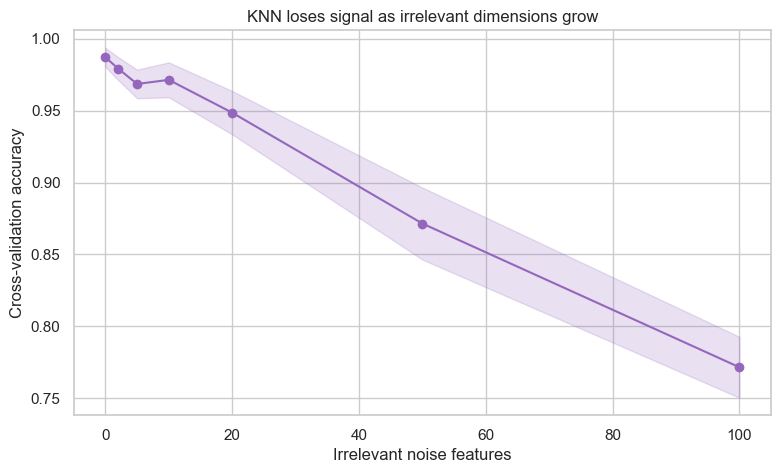

In [5]:
sample_rows = 1400
signal_dimensions = 2
noise_dimensions = [0, 2, 5, 10, 20, 50, 100]
synthetic_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for noise_count in noise_dimensions:
    X, y = make_classification(
        n_samples=sample_rows,
        n_features=signal_dimensions + noise_count,
        n_informative=signal_dimensions,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        class_sep=1.25,
        flip_y=0.03,
        random_state=RANDOM_STATE,
    )
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights="distance"))
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", error_score="raise")
    synthetic_rows.append({"noise_features": noise_count, "total_features": signal_dimensions + noise_count, "mean_accuracy": scores.mean(), "std_accuracy": scores.std()})
synthetic_results = pd.DataFrame(synthetic_rows)
display(synthetic_results.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(synthetic_results["noise_features"], synthetic_results["mean_accuracy"], marker="o", color="tab:purple")
ax.fill_between(synthetic_results["noise_features"], synthetic_results["mean_accuracy"] - synthetic_results["std_accuracy"], synthetic_results["mean_accuracy"] + synthetic_results["std_accuracy"], alpha=0.2, color="tab:purple")
ax.set_xlabel("Irrelevant noise features")
ax.set_ylabel("Cross-validation accuracy")
ax.set_title("KNN loses signal as irrelevant dimensions grow")
plt.show()

## ۲. هندسه را شبیه‌سازی کنید

شبیه‌سازی نخست از چند بُعد نقاط نرمال نمونه می‌گیرد و فاصله‌ها را از یک پرس‌وجو تا همهٔ نقطه‌های دیگر اندازه می‌گیرد. نمودارها دو اثر مرتبط را نشان می‌دهند: فاصله‌ها با بُعد رشد می‌کنند و فاصلهٔ نزدیک و دور از نظر نسبی کم‌تر جدا می‌شوند. مقایسهٔ histogram تمرکز را قابل دیدن می‌کند: توزیع فاصلهٔ پُربعد نسبت به میانگینش باریک است.

این آزمایش از ویژگی‌های مستقل مصنوعی استفاده می‌کند تا هندسه کنترل‌پذیر باشد. دادهٔ واقعی می‌تواند هم‌بستگی، خوشه و مقیاس متفاوت داشته باشد. این جزئیات مهم‌اند، اما شبیه‌سازی هشدار می‌دهد افزودن بُعد بدون ساختار مفید می‌تواند شباهت محلی را کم‌اطلاع کند.

In [6]:
iris_path = Path("../../../Datasets/Classification/iris.csv")
iris = pd.read_csv(iris_path)
iris_X = iris.drop(columns="classification")
iris_y = iris["classification"]

display(iris.head())
display(iris.dtypes.rename("dtype").to_frame())
display(iris_y.value_counts().rename("count").to_frame())

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


,dtype
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
classification,object


,count
classification,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## ۳. ویژگی نامرتبط سیگنال را رقیق می‌کند

مسئلهٔ طبقه‌بندی مصنوعی با دو بُعد اطلاع‌رسان می‌سازیم و سپس ویژگی‌های نویز تصادفی اضافه می‌کنیم. سیگنال کلاس ثابت می‌ماند، اما KNN باید فاصله را در همهٔ بُعدها محاسبه کند. ویژگی‌های تصادفی تغییری می‌افزایند که با برچسب مرتبط نیست. در نهایت نویز می‌تواند اختلاف مختصات اطلاع‌رسان را بپوشاند و همسایهٔ واقعی دیگر به‌طور قابل اعتماد نزدیک نباشد.

ارزیابی از اعتبارسنجی stratified و pipeline دارای StandardScaler استفاده می‌کند. مقیاس‌بندی همچنان درست است، زیرا اثر عددی مختصات را قابل مقایسه می‌کند. اما ویژگی تصادفی را حذف و سیگنال ازدست‌رفته را بازنمی‌گرداند. این تفاوت مرکزی است: پیش‌پردازش واحدها را اصلاح می‌کند، اما انتخاب ویژگی برای حذف اطلاعات بی‌فایده لازم است.

,noise_features,total_features,mean_accuracy,std_accuracy
0,0,4,0.960,0.039
1,2,6,0.907,0.044
2,5,9,0.840,0.057
3,10,14,0.813,0.062
4,20,24,0.813,0.105
5,50,54,0.727,0.053


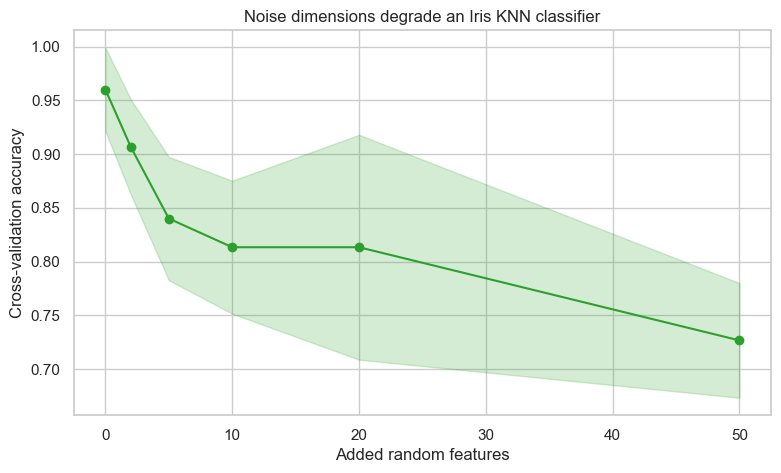

In [7]:
iris_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
iris_rows = []
noise_grid = [0, 2, 5, 10, 20, 50]
for noise_count in noise_grid:
    augmented_X = iris_X.copy()
    for feature_index in range(noise_count):
        augmented_X[f"noise_{feature_index + 1}"] = rng.normal(size=len(augmented_X))
    iris_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9, weights="distance"))
    iris_scores = cross_val_score(iris_model, augmented_X, iris_y, cv=iris_cv, scoring="accuracy", error_score="raise")
    iris_rows.append({"noise_features": noise_count, "total_features": augmented_X.shape[1], "mean_accuracy": iris_scores.mean(), "std_accuracy": iris_scores.std()})
iris_results = pd.DataFrame(iris_rows)
display(iris_results.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iris_results["noise_features"], iris_results["mean_accuracy"], marker="o", color="tab:green")
ax.fill_between(iris_results["noise_features"], iris_results["mean_accuracy"] - iris_results["std_accuracy"], iris_results["mean_accuracy"] + iris_results["std_accuracy"], alpha=0.2, color="tab:green")
ax.set_xlabel("Added random features")
ax.set_ylabel("Cross-validation accuracy")
ax.set_title("Noise dimensions degrade an Iris KNN classifier")
plt.show()

## ۴. Iris را پیش از افزودن نویز بررسی کنید

Iris چهار اندازه‌گیری عددی گل و یک برچسب دسته‌ای دارد. سطرهای نخست و نوع داده‌ها پیش از مدل‌سازی بررسی می‌شوند. با چند اندازه‌گیری معنادار، KNN همسایگی محلی مفیدی می‌سازد. سپس ستون‌های نرمال تصادفی به همان سطرها اضافه و اعتبارسنجی تکرار می‌شود. ستون‌های جدید اطلاعاتی دربارهٔ کلاس گل ندارند، اما فاصله با آن‌ها طوری رفتار می‌کند که گویی مهم‌اند.

این آزمایش واقعی عمداً ساده است. در تولید، بُعد نامرتبط شاید شناسه، متغیر تکراری، دستهٔ بدکدگذاری‌شده، حسگر نویزی یا proxy باشد. نویز تصادفی جایگزین صادقی است، زیرا می‌دانیم هیچ سیگنالی برای هدف ندارد.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=0.25, stratify=iris_y, random_state=RANDOM_STATE)
noise_count = 50
iris_train_noisy = X_train.copy()
iris_test_noisy = X_test.copy()
for feature_index in range(noise_count):
    iris_train_noisy[f"noise_{feature_index + 1}"] = rng.normal(size=len(iris_train_noisy))
    iris_test_noisy[f"noise_{feature_index + 1}"] = rng.normal(size=len(iris_test_noisy))

raw_noisy_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9, weights="distance"))
pca_model = make_pipeline(StandardScaler(), PCA(n_components=4, random_state=RANDOM_STATE), KNeighborsClassifier(n_neighbors=9, weights="distance"))
clean_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=9, weights="distance"))

models = {
    "Clean four features": (clean_model, X_train, X_test),
    "Fifty noisy features added": (raw_noisy_model, iris_train_noisy, iris_test_noisy),
    "Noisy features with PCA": (pca_model, iris_train_noisy, iris_test_noisy),
}
mitigation_rows = []
for model_name, (model, train_features, test_features) in models.items():
    model.fit(train_features, y_train)
    mitigation_rows.append({"model": model_name, "test_accuracy": model.score(test_features, y_test)})
mitigation_results = pd.DataFrame(mitigation_rows)
display(mitigation_results.round(3))

,model,test_accuracy
0,Clean four features,0.974
1,Fifty noisy features added,0.789
2,Noisy features with PCA,0.763


## ۵. راه‌کار: نمایش را کم یا بازطراحی کنید

انتخاب ویژگی متغیرهایی را که به کار کمک نمی‌کنند حذف می‌کند. این انتخاب می‌تواند از دانش دامنه، آمار filter، اهمیت مدل یا جست‌وجوی اعتبارسنجی استفاده کند. کاهش بُعد، ویژگی‌ها را به مؤلفه‌های کم‌تری فشرده می‌کند. PCA جهت‌های واریانس بالا را می‌یابد، نه لزوماً جهت‌های مفید برای برچسب. می‌تواند نویز و ذخیره‌سازی را کاهش دهد، اما شاید ویژگی کم‌واریانس پیش‌بینی‌کنندهٔ کلاس نادر را دور بیندازد.

نوت‌بوک سه نمایش را مقایسه می‌کند: چهار ویژگی اصلی Iris، همان ویژگی‌ها با پنجاه ستون تصادفی و نمایش نویزی پس از نگه‌داشتن چهار مؤلفه با PCA. این یک تصویرسازی است، نه دستور همگانی. تعداد مؤلفه و روش انتخاب باید با اعتبارسنجی فقط روی آموزش تعیین شوند.

,features,megabytes_for_10000_rows
0,2,0.153
1,5,0.381
2,10,0.763
3,25,1.907
4,50,3.815
5,100,7.629
6,200,15.259
7,500,38.147


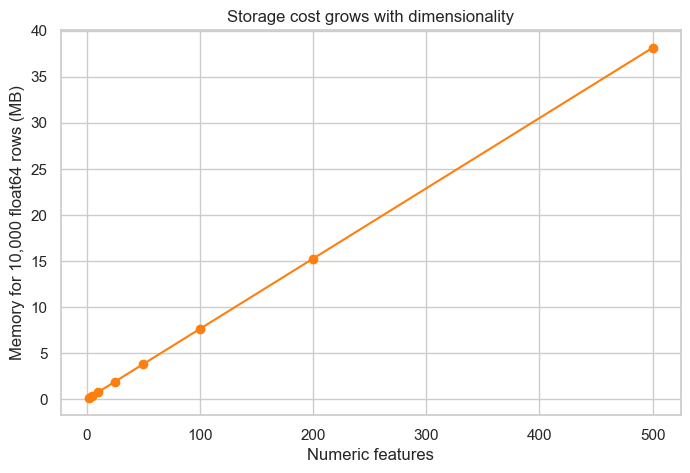

In [9]:
feature_counts = [2, 5, 10, 25, 50, 100, 200, 500]
memory_rows = []
for feature_count in feature_counts:
    array = np.empty((10000, feature_count), dtype=np.float64)
    memory_rows.append({"features": feature_count, "megabytes_for_10000_rows": array.nbytes / (1024 ** 2)})
memory_results = pd.DataFrame(memory_rows)
display(memory_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(memory_results["features"], memory_results["megabytes_for_10000_rows"], marker="o", color="tab:orange")
ax.set_xlabel("Numeric features")
ax.set_ylabel("Memory for 10,000 float64 rows (MB)")
ax.set_title("Storage cost grows with dimensionality")
plt.show()

## ۶. پیامدهای محاسباتی

بُعد زیاد فقط به دقت آماری آسیب نمی‌زند. ذخیرهٔ $n$ مثال float64 با $d$ ویژگی پیش از index، برچسب و overhead حدود $8nd$ بایت می‌خواهد. جست‌وجوی دقیق هم برای هر پرس‌وجو اختلاف‌های مختصات زیادی را محاسبه می‌کند. بُعد بیشتر memory traffic، محاسبهٔ فاصله و اغلب latency را بالا می‌برد.

indexهای کارآمد مانند KD-tree عمدتاً در بُعد پایین یا متوسط کمک می‌کنند. با رشد بُعد، pruning کم‌اثر و رفتارشان به brute force نزدیک می‌شود. سامانهٔ همسایهٔ تقریبی، embedding یادگرفته‌شده، hashing، فشرده‌سازی ویژگی و pre-filter پاسخ‌های مهندسی رایج‌اند. آن‌ها exactness، حافظه، زمان ساخت یا پیچیدگی را برای سرعت عملی مبادله می‌کنند.

In [10]:
query = iris_X.iloc[[0]]
clean_scaler = StandardScaler().fit(iris_X)
scaled_iris = clean_scaler.transform(iris_X)
query_scaled = clean_scaler.transform(query)
clean_distances = np.linalg.norm(scaled_iris[1:] - query_scaled, axis=1)

noisy_full = iris_X.copy()
for feature_index in range(50):
    noisy_full[f"noise_{feature_index + 1}"] = rng.normal(size=len(noisy_full))
noisy_scaler = StandardScaler().fit(noisy_full)
scaled_noisy = noisy_scaler.transform(noisy_full)
noisy_query = noisy_full.iloc[[0]]
noisy_distances = np.linalg.norm(scaled_noisy[1:] - noisy_scaler.transform(noisy_query), axis=1)

contrast_table = pd.DataFrame({
    "representation": ["Clean Iris features", "Iris plus 50 random features"],
    "nearest_distance": [clean_distances.min(), noisy_distances.min()],
    "farthest_distance": [clean_distances.max(), noisy_distances.max()],
    "relative_contrast": [
        (clean_distances.max() - clean_distances.min()) / clean_distances.min(),
        (noisy_distances.max() - noisy_distances.min()) / noisy_distances.min(),
    ],
})
display(contrast_table.round(3))

,representation,nearest_distance,farthest_distance,relative_contrast
0,Clean Iris features,0.121,5.594,45.171
1,Iris plus 50 random features,8.345,12.296,0.473


## ۷. بررسی کنتراست محلی

محاسبهٔ نهایی، کنتراست فاصله را برای یک پرس‌وجوی Iris در نمایش چهارویژگی تمیز و همان نمایش با پنجاه ویژگی تصادفی مقایسه می‌کند. مقدار دقیق با نویز تغییر می‌کند، اما الگو مهم است: جدایی نسبی نزدیک‌ترین و دورترین مشاهده ضعیف‌تر می‌شود. نزدیک‌ترین همسایه در فضای نویزی شاید دیگر همسایهٔ معنایی قابل اعتماد نباشد.

به این مسئله با کم‌کردن کورکورانهٔ K یا عوض‌کردن یک معیار پاسخ ندهید. از نمایش آغاز کنید: نشت و شناسه را حذف کنید، ویژگی عددی معتبر را استاندارد کنید، دسته‌ها را آگاهانه کدگذاری کنید، متغیرهای مفید را انتخاب و با تقسیم‌های شبیه استقرار اعتبارسنجی کنید. سپس وقتی داده و latency لازم می‌کنند کاهش بُعد یا جست‌وجوی تقریبی را بررسی کنید.

## ۸. تمرین‌ها و جمع‌بندی

1. جدایی کلاس مصنوعی را تغییر دهید و ببینید KNN چه مقدار نویز را تحمل می‌کند.
2. با افزودن ویژگی تصادفی، فاصلهٔ اقلیدسی و منهتن را مقایسه کنید.
3. روی Iris نویزی، PCA با 2، 4 و 8 مؤلفه را اعتبارسنجی کنید.
4. یک ویژگی Iris را چند بار تکرار کنید. چرا افزونگی هم‌بسته نیز به فاصله آسیب می‌زند؟
5. baseline انتخاب ویژگی بسازید که فقط اندازه‌های گلبرگ را نگه می‌دارد و آن را با هر چهار ویژگی Iris مقایسه کنید.

### جمع‌بندی

نفرین بُعد تمایز نزدیک و دور را کم می‌کند. برای KNN، این یعنی با انباشت بُعدهای بی‌فایده همسایگی کم‌اعتمادتر می‌شود. تمرکز فاصله را اندازه گرفتیم، افت دقت با ویژگی نامرتبط را نشان دادیم، اثر را روی دادهٔ واقعی Iris بازتولید کردیم و PCA و انتخاب ویژگی را به‌عنوان راه‌کار دیدیم. یادگیری مبتنی بر نمونهٔ خوب با نمایش فشرده و معنادار و طراحی اعتبارسنجی صادقانه آغاز می‌شود.